<a href="https://colab.research.google.com/github/llekomtsev/Lab1_2026_Ai/blob/main/Lab1_StanfordDogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib scikit-learn

In [2]:
!pip install --upgrade torch torchvision

In [3]:
!pip install kagglehub

# Загрузить kaggle.json
from google.colab import files
files.upload()   # мой kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
import kagglehub
import os

# Загружаем последнюю версию датасета
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.
Dataset downloaded to: /kaggle/input/stanford-dogs-dataset


100%|██████████| 750M/750M [00:07<00:00, 104MB/s]

Extracting files...


Датасет загружен в: /root/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2
Найдена папка с изображениями: /root/.cache/kagglehub/datasets/jessicali9530/stanford-dogs-dataset/versions/2/images/Images
Количество классов: 120
Размеры: Train 14405, Val 3087, Test 3088
Количество классов в train_dataset: 120
Первые 10 классов: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound']
Топ-10 меток в train_loader: [(np.int64(2), 174), (np.int64(9), 167), (np.int64(103), 159), (np.int64(26), 159), (np.int64(19), 156), (np.int64(101), 155), (np.int64(4), 153), (np.int64(107), 153), (np.int64(106), 152), (np.int64(88), 150)]
Пример формы изображений: torch.Size([64, 3, 224, 224])
Пример меток: tensor([13, 25, 27, 44, 19,  8, 64, 62, 22, 52])

=== Experiment 1: Pretrained + A

100%|██████████| 4.73M/4.73M [00:00<00:00, 65.0MB/s]


exp1_adam | Epoch 1/15 | Train Loss: 4.7681 | Val Loss: 4.5607 | Val F1: 0.0193
exp1_adam | Epoch 2/15 | Train Loss: 4.0814 | Val Loss: 3.3770 | Val F1: 0.1804
exp1_adam | Epoch 3/15 | Train Loss: 3.2599 | Val Loss: 2.8505 | Val F1: 0.2717
exp1_adam | Epoch 4/15 | Train Loss: 2.9175 | Val Loss: 2.3152 | Val F1: 0.3849
exp1_adam | Epoch 5/15 | Train Loss: 2.6878 | Val Loss: 2.2678 | Val F1: 0.3925
exp1_adam | Epoch 6/15 | Train Loss: 2.5792 | Val Loss: 2.0753 | Val F1: 0.4347
exp1_adam | Epoch 7/15 | Train Loss: 2.4597 | Val Loss: 1.9422 | Val F1: 0.4689
exp1_adam | Epoch 8/15 | Train Loss: 2.3682 | Val Loss: 1.9253 | Val F1: 0.4776
exp1_adam | Epoch 9/15 | Train Loss: 2.2809 | Val Loss: 1.9360 | Val F1: 0.4743
exp1_adam | Epoch 10/15 | Train Loss: 2.2360 | Val Loss: 2.0236 | Val F1: 0.4636
exp1_adam | Epoch 11/15 | Train Loss: 2.2003 | Val Loss: 1.6994 | Val F1: 0.5295
exp1_adam | Epoch 12/15 | Train Loss: 2.1473 | Val Loss: 1.7887 | Val F1: 0.5235
exp1_adam | Epoch 13/15 | Train Loss:

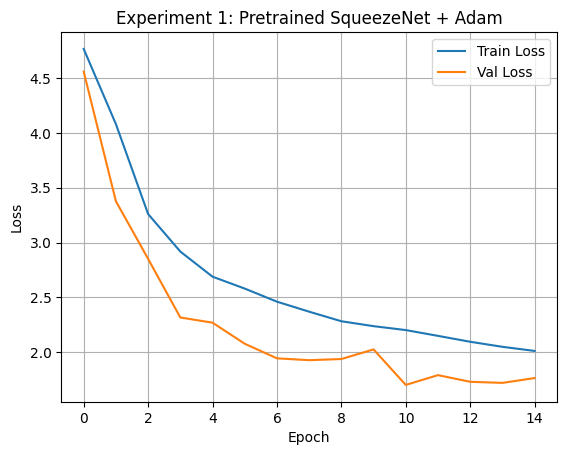

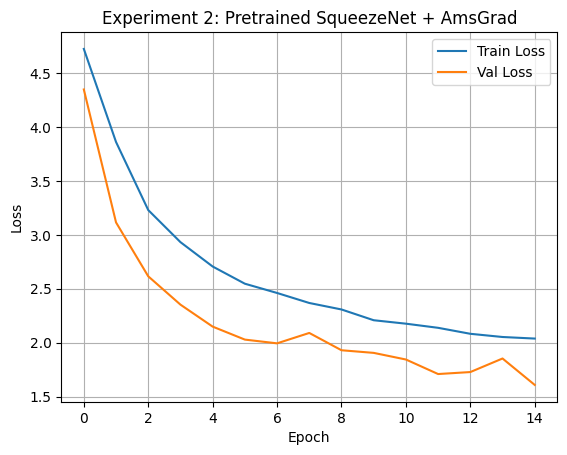

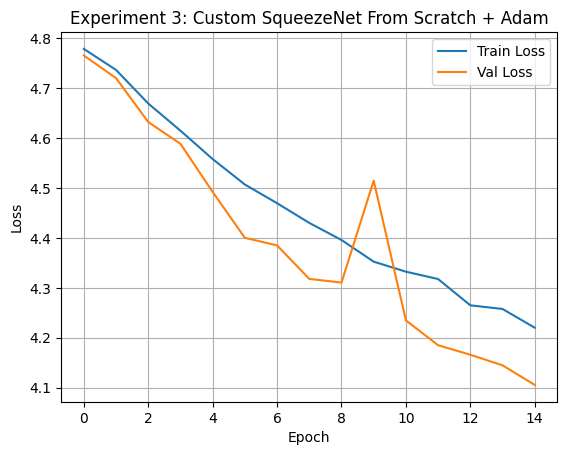

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.models import squeezenet1_1, SqueezeNet1_1_Weights
import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import os
import kagglehub

#1. Параметры
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
NUM_EPOCHS = 15
NUM_CLASSES = 120
IMG_SIZE = 224

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

#2. Трансформации
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),          # случайный кроп с масштабированием
    transforms.RandomHorizontalFlip(p=0.5),          # отражение по горизонтали
    transforms.RandomRotation(degrees=10),           # небольшой поворот
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # изменение цвета
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.5),  # гауссово размытие
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

#3. Загрузка датасета через kagglehub
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")
print("Датасет загружен в:", path)

# Возможные пути к папке с изображениями (где подпапки пород содержат jpg)
candidates = [
    os.path.join(path, 'images', 'Images'),        # вариант с подпапками пород внутри images/Images
    os.path.join(path, 'images'),                  # сразу в images
    os.path.join(path, 'Images'),
    os.path.join(path, 'annotations', 'Annotation'), # аннотации, проверим на всякий случай
    path
]

images_dir = None
for candidate in candidates:
    if os.path.exists(candidate):
        subdirs = [d for d in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, d))]
        if len(subdirs) >= 100:   # ожидаем 120 классов
            # Дополнительная проверка: в первой подпапке должны быть изображения
            first_class = subdirs[0]
            class_path = os.path.join(candidate, first_class)
            if os.path.isdir(class_path):
                files = os.listdir(class_path)
                if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
                    images_dir = candidate
                    print(f"Найдена папка с изображениями: {images_dir}")
                    print(f"Количество классов: {len(subdirs)}")
                    break
                else:
                    print(f"В папке {candidate} в подпапках нет изображений, пропускаем.")
        else:
            # Может, внутри есть ещё одна папка? Например, images/Images, но мы уже проверили.
            pass

if images_dir is None:
    # Диагностика
    print("Не удалось автоматически найти папку с изображениями.")
    print("Содержимое корня датасета:")
    for item in os.listdir(path):
        print(f"  {item}")
    for cand in candidates:
        if os.path.exists(cand):
            print(f"\nСодержимое {cand}:")
            sub = os.listdir(cand)
            for s in sub[:10]:
                print(f"  {s}")
            if len(sub) > 10:
                print("  ...")
    raise RuntimeError("Не удалось найти папку с подпапками пород, содержащими изображения.")

# Создаём датасеты с разными трансформациями
train_dataset = datasets.ImageFolder(root=images_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=images_dir, transform=eval_transform)
test_dataset  = datasets.ImageFolder(root=images_dir, transform=eval_transform)

total = len(train_dataset)
train_len = int(0.7 * total)
val_len   = int(0.15 * total)
test_len  = total - train_len - val_len

torch.manual_seed(42)
indices = list(range(total))
train_indices, val_indices, test_indices = random_split(indices, [train_len, val_len, test_len])

train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_subset   = torch.utils.data.Subset(val_dataset,   val_indices.indices)
test_subset  = torch.utils.data.Subset(test_dataset,  test_indices.indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Размеры: Train {len(train_subset)}, Val {len(val_subset)}, Test {len(test_subset)}")

# Проверка данных
print("Количество классов в train_dataset:", len(train_dataset.classes))
print("Первые 10 классов:", train_dataset.classes[:10])

# Проверка, что метки разнообразны
from collections import Counter
counter = Counter()
for _, labels in train_loader:
    counter.update(labels.numpy())
print("Топ-10 меток в train_loader:", counter.most_common(10))

# Проверка формы изображений
for images, labels in train_loader:
    print("Пример формы изображений:", images.shape)
    print("Пример меток:", labels[:10])
    break

#4. Собственная реализация SqueezeNet и функции создания моделей

class FireModule(nn.Module):
    """
    Fire-модуль архитектуры SqueezeNet.

    Структура:
    1. squeeze-свёртка 1x1 уменьшает количество каналов;
    2. expand-свёртка 1x1 извлекает признаки;
    3. expand-свёртка 3x3 извлекает признаки с учётом соседних пикселей;
    4. выходы expand-веток объединяются по каналам.
    """

    def __init__(self, in_channels, squeeze_channels, expand1x1_channels, expand3x3_channels):
        super(FireModule, self).__init__()

        self.squeeze = nn.Conv2d(
            in_channels=in_channels,
            out_channels=squeeze_channels,
            kernel_size=1
        )

        self.squeeze_activation = nn.ReLU(inplace=True)

        self.expand1x1 = nn.Conv2d(
            in_channels=squeeze_channels,
            out_channels=expand1x1_channels,
            kernel_size=1
        )

        self.expand1x1_activation = nn.ReLU(inplace=True)

        self.expand3x3 = nn.Conv2d(
            in_channels=squeeze_channels,
            out_channels=expand3x3_channels,
            kernel_size=3,
            padding=1
        )

        self.expand3x3_activation = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.squeeze_activation(self.squeeze(x))

        out1 = self.expand1x1_activation(self.expand1x1(x))
        out2 = self.expand3x3_activation(self.expand3x3(x))

        # Объединяем две expand-ветки по каналам
        return torch.cat([out1, out2], dim=1)


class CustomSqueezeNet(nn.Module):
    """
    Собственная реализация архитектуры SqueezeNet 1.1.
    Используется для эксперимента From Scratch + Adam.
    """

    def __init__(self, num_classes=120):
        super(CustomSqueezeNet, self).__init__()

        self.num_classes = num_classes

        self.features = nn.Sequential(
            # Начальная свёртка: RGB изображение -> 64 карты признаков
            nn.Conv2d(3, 64, kernel_size=3, stride=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            # Fire 2, Fire 3
            FireModule(64, 16, 64, 64),        # выход: 64 + 64 = 128 каналов
            FireModule(128, 16, 64, 64),       # выход: 128 каналов
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            # Fire 4, Fire 5
            FireModule(128, 32, 128, 128),     # выход: 256 каналов
            FireModule(256, 32, 128, 128),     # выход: 256 каналов
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),

            # Fire 6, Fire 7, Fire 8, Fire 9
            FireModule(256, 48, 192, 192),     # выход: 384 каналов
            FireModule(384, 48, 192, 192),     # выход: 384 каналов
            FireModule(384, 64, 256, 256),     # выход: 512 каналов
            FireModule(512, 64, 256, 256),     # выход: 512 каналов
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Conv2d(512, num_classes, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        # Было: [batch_size, num_classes, 1, 1]
        # Стало: [batch_size, num_classes]
        x = torch.flatten(x, 1)

        return x

    def _initialize_weights(self):
        """
        Инициализация весов для обучения с нуля.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                if m.out_channels == self.num_classes:
                    nn.init.normal_(m.weight, mean=0.0, std=0.01)
                else:
                    nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)


def create_pretrained_model():
    """
    Создание предобученной SqueezeNet 1.1 из torchvision.
    Используется для экспериментов:
    1. Pretrained + Adam
    2. Pretrained + AmsGrad
    """
    weights = SqueezeNet1_1_Weights.IMAGENET1K_V1
    model = squeezenet1_1(weights=weights)

    # Заменяем последний классификационный слой:
    # было 1000 классов ImageNet, стало 120 пород собак
    model.classifier[1] = nn.Conv2d(512, NUM_CLASSES, kernel_size=(1, 1))
    model.num_classes = NUM_CLASSES

    return model.to(DEVICE)


def create_custom_squeezenet_from_scratch():
    """
    Создание собственной реализации SqueezeNet 1.1 без предобученных весов.
    Используется для эксперимента:
    3. From Scratch + Adam
    """
    model = CustomSqueezeNet(num_classes=NUM_CLASSES)
    return model.to(DEVICE)

#5.Функция оценки метрик
def compute_metrics(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    return precision, recall, f1

#6.Функция обучения
def train_model(model, optimizer, criterion, train_loader, val_loader, epochs, model_name):
    best_val_f1 = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        _, _, val_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted', zero_division=0
        )

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(val_f1)

        print(f"{model_name} | Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f}")


        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f"best_{model_name}.pth")

    return history, best_val_f1

#7.Проведение трех экспериментов
criterion = nn.CrossEntropyLoss()

print("\n=== Experiment 1: Pretrained + Adam ===")
model1 = create_pretrained_model()
optimizer1 = optim.Adam(model1.parameters(), lr=1e-4, amsgrad=False)
history1, _ = train_model(model1, optimizer1, criterion, train_loader, val_loader, NUM_EPOCHS, "exp1_adam")
model1.load_state_dict(torch.load("best_exp1_adam.pth"))
prec1, rec1, f1_1 = compute_metrics(model1, test_loader)
print(f"Test results: Precision={prec1:.4f}, Recall={rec1:.4f}, F1={f1_1:.4f}")

print("\n=== Experiment 2: Pretrained + AmsGrad ===")
model2 = create_pretrained_model()
optimizer2 = optim.Adam(model2.parameters(), lr=1e-4, amsgrad=True)
history2, _ = train_model(model2, optimizer2, criterion, train_loader, val_loader, NUM_EPOCHS, "exp2_amsgrad")
model2.load_state_dict(torch.load("best_exp2_amsgrad.pth"))
prec2, rec2, f1_2 = compute_metrics(model2, test_loader)
print(f"Test results: Precision={prec2:.4f}, Recall={rec2:.4f}, F1={f1_2:.4f}")

print("\n=== Experiment 3: From Scratch + Adam ===")
model3 = create_custom_squeezenet_from_scratch()
optimizer3 = optim.Adam(model3.parameters(), lr=1e-4, amsgrad=False)
history3, _ = train_model(model3, optimizer3, criterion, train_loader, val_loader, NUM_EPOCHS, "exp3_custom_scratch")
model3.load_state_dict(torch.load("best_exp3_custom_scratch.pth"))
prec3, rec3, f1_3 = compute_metrics(model3, test_loader)
print(f"Test results: Precision={prec3:.4f}, Recall={rec3:.4f}, F1={f1_3:.4f}")

print("\n" + "="*50)
print("FINAL COMPARISON ON TEST SET")
print("="*50)

print(f"Pretrained SqueezeNet + Adam      | Precision: {prec1:.4f} | Recall: {rec1:.4f} | F1: {f1_1:.4f}")
print(f"Pretrained SqueezeNet + AmsGrad   | Precision: {prec2:.4f} | Recall: {rec2:.4f} | F1: {f1_2:.4f}")
print(f"Custom SqueezeNet Scratch + Adam  | Precision: {prec3:.4f} | Recall: {rec3:.4f} | F1: {f1_3:.4f}")

def plot_history(history, title):
    plt.figure()
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history1, "Experiment 1: Pretrained SqueezeNet + Adam")
plot_history(history2, "Experiment 2: Pretrained SqueezeNet + AmsGrad")
plot_history(history3, "Experiment 3: Custom SqueezeNet From Scratch + Adam")